# Multi-Stage Attack Detection Using Random Forest (Baseline)
## Recreating the IDS framework from *"Multi-stage Attack Detection and Prediction Using GNN"*

**Paper:** Friji et al. — 3-stage IDS inspired by Lockheed Martin's Cyber Kill Chain  
**This notebook:** Random Forest baseline with **stratified global IP-split**

### Design:
1. **3-stage CKC mapping** per Figure 3
2. **Stratified global IP-split** — 20% of unique src_ips from each stage → test set (ensures every stage has samples in both train & test)
3. **3 binary classifiers** (Stage_i vs Other)
4. **`src_ip_bytes` removed** per paper
5. Stage 3 prediction feasibility study


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_fscore_support)
from sklearn.model_selection import cross_val_predict, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')
print("Libraries loaded.")


Libraries loaded.


## Applying Timestamp to dataset

In [46]:
import pandas as pd
import glob
import os
from tqdm import tqdm  # pip install tqdm dulu kalo belum ada, biar keliatan loadingnya

# 1. Load dataset lu yang sekarang
print("Loading train_test dataset...")
df_target = pd.read_csv('train_test_network.csv')

# Path ke folder dataset asli berdasarkan screenshot lu
folder_path = r'C:\Users\62811\Desktop\TA apasih\Processed_Network_dataset'
all_files = glob.glob(os.path.join(folder_path, "*.csv"))

# 2. Tentukan identifier unik buat nge-join (5-Tuple + attack type)
# Pastikan nama-nama kolom ini sesuai sama yang ada di CSV lu
join_cols = ['src_ip', 'src_port', 'dst_ip', 'dst_port', 'type']
target_time_col = 'ts' # Ganti jadi 'timestamp' atau 'waktu' kalo di dataset aslinya beda

# Kita pake dictionary mapping biar ga makan RAM
timestamp_mapping = {}

print(f"Mengekstrak {target_time_col} dari {len(all_files)} file original...")
for file in tqdm(all_files):
    # Cuma load kolom identifier + timestamp biar enteng
    try:
        df_orig = pd.read_csv(file, usecols=join_cols + [target_time_col])
        
        # Buang duplikat identifier di dalam satu file (ambil kemunculan pertama)
        df_orig = df_orig.drop_duplicates(subset=join_cols)
        
        # Bikin zip dari kolom join sebagai keys
        keys = zip(*[df_orig[c] for c in join_cols])
        # Update dictionary
        timestamp_mapping.update(dict(zip(keys, df_orig[target_time_col])))
        
    except ValueError:
        # Kalo ada file yang format kolomnya beda, lewatin aja
        print(f"Skipping {os.path.basename(file)} (kolom tidak cocok)")
        continue

# 3. Tempel timestamp ke dataset target lu
print("Mapping timestamp ke train_test_network.csv...")
target_keys = zip(*[df_target[c] for c in join_cols])

# Ambil timestamp dari dictionary, kalo ga ketemu isi pake pd.NaT (Not a Time)
df_target['timestamp'] = [timestamp_mapping.get(k, pd.NaT) for k in target_keys]

# 4. Evaluasi
missing_ts = df_target['timestamp'].isna().sum()
total_rows = len(df_target)
print("\n" + "="*50)
print(f"Selesai! Berhasil mapping {total_rows - missing_ts} dari {total_rows} baris.")
if missing_ts > 0:
    print(f"WARNING: Ada {missing_ts} baris yang ga nemu timestampnya.")

# 5. Save output
output_name = 'train_test_network_with_ts.csv'
df_target.to_csv(output_name, index=False)
print(f"Data tersimpan sebagai: {output_name}")

Loading train_test dataset...
Mengekstrak ts dari 23 file original...


100%|██████████| 23/23 [00:41<00:00,  1.79s/it]


Mapping timestamp ke train_test_network.csv...

Selesai! Berhasil mapping 211043 dari 211043 baris.
Data tersimpan sebagai: train_test_network_with_ts.csv


In [47]:
import pandas as pd
import numpy as np

# 1. Load data yang udah ada timestamp-nya
print("Loading data...")
df = pd.read_csv('train_test_network_with_ts.csv')

# 2. Pastikan kolom timestamp berformat datetime
# errors='coerce' bakal ubah format error jadi NaT (Not a Time)
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# Drop baris yang timestamp-nya kosong (jika ada) biar kalkulasi ga error
df = df.dropna(subset=['timestamp'])

print("Mengkalkulasi Time Delta...")
# 3. URUTKAN data berdasarkan IP Source dan Waktu
# Ini wajib banget biar hitungan jedanya bener secara kronologis per IP
df = df.sort_values(by=['src_ip', 'timestamp'])

# 4. Hitung selisih waktu (jeda) dengan baris sebelumnya dari IP yang sama
df['time_delta'] = df.groupby('src_ip')['timestamp'].diff().dt.total_seconds()

# Koneksi pertama dari setiap IP pasti nilai diff-nya NaN, kita isi aja 0
df['time_delta'] = df['time_delta'].fillna(0)

# 5. DROP TIMESTAMP MENTAH (Ini kunci biar ga Data Leakage!)
df = df.drop(columns=['timestamp'])

# (Opsional) Shuffle ulang datanya biar urutannya random lagi untuk training
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# 6. Save data
output_name = 'train_test_network_feature_engineered.csv'
df.to_csv(output_name, index=False)

print(f"\nSelesai! Fitur 'time_delta' berhasil dibuat.")
print(f"Data disimpan sebagai: {output_name}")

# Intip dikit hasilnya
print("\nPreview kolom yang relevan:")
print(df[['src_ip', 'time_delta', 'type']].head(10))

Loading data...
Mengkalkulasi Time Delta...

Selesai! Fitur 'time_delta' berhasil dibuat.
Data disimpan sebagai: train_test_network_feature_engineered.csv

Preview kolom yang relevan:
          src_ip    time_delta        type
0   192.168.1.31  0.000000e+00    password
1  192.168.1.195  0.000000e+00      normal
2  192.168.1.152  1.500000e-08      normal
3   192.168.1.37  0.000000e+00  ransomware
4  192.168.1.193  0.000000e+00    backdoor
5  192.168.1.152  0.000000e+00      normal
6   192.168.1.31  0.000000e+00    scanning
7  192.168.1.152  0.000000e+00      normal
8  192.168.1.152  0.000000e+00      normal
9   192.168.1.30  0.000000e+00         dos


In [48]:
print(f"Dataset shape: {df.shape}")
print(f"\nAttack type distribution:")
print(df['type'].value_counts())


Dataset shape: (211043, 45)

Attack type distribution:
normal        50000
password      20000
ransomware    20000
backdoor      20000
scanning      20000
dos           20000
injection     20000
ddos          20000
xss           20000
mitm           1043
Name: type, dtype: int64


## 1. Stage Mapping (per Figure 3)

| Stage | CKC Phase | ToN IoT Attacks |
|-------|-----------|-----------------|
| **Stage 1** — Reconnaissance | Reconnaissance | scanning |
| **Stage 2** — Privilege Escalation | Delivery + Exploitation | xss, ddos, dos, injection, mitm, password |
| **Stage 3** — Access Exploitation | Installation + C2 + Actions | backdoor, ransomware |


In [49]:
STAGE_MAP = {
    'normal': 0, 'scanning': 1,
    'xss': 2, 'ddos': 2, 'dos': 2, 'injection': 2, 'mitm': 2, 'password': 2,
    'backdoor': 3, 'ransomware': 3,
}
df['stage'] = df['type'].map(STAGE_MAP)
assert df['stage'].isna().sum() == 0

print("Stage Distribution:")
print(df['stage'].value_counts().sort_index())
for s in sorted(df['stage'].unique()):
    print(f"  Stage {s}: {list(df[df['stage']==s]['type'].unique())}")


Stage Distribution:
0     50000
1     20000
2    101043
3     40000
Name: stage, dtype: int64
  Stage 0: ['normal']
  Stage 1: ['scanning']
  Stage 2: ['password', 'dos', 'injection', 'ddos', 'xss', 'mitm']
  Stage 3: ['ransomware', 'backdoor']


## 2. Attack Chain Analysis (dst_ip across stages)


In [50]:
dst_s1 = set(df[df['stage']==1]['dst_ip'].unique())
dst_s2 = set(df[df['stage']==2]['dst_ip'].unique())
dst_s3 = set(df[df['stage']==3]['dst_ip'].unique())

print("Destination IPs targeted per stage:")
print(f"  Stage 1: {len(dst_s1)} | Stage 2: {len(dst_s2)} | Stage 3: {len(dst_s3)}")

dst_s1_and_s2 = dst_s1 & dst_s2
print(f"\nIPs hit by BOTH S1 & S2:  {len(dst_s1_and_s2)}")
print(f"  Also hit by S3: {len(dst_s1_and_s2 & dst_s3)}")
print(f"  NOT hit by S3:  {len(dst_s1_and_s2 - dst_s3)}")

print(f"\nIPs with S2 (no S1) then S3: {len((dst_s2 - dst_s1) & dst_s3)}")
print(f"IPs with S3 only:            {len(dst_s3 - dst_s1 - dst_s2)}")

# Key targets breakdown
all_attacked = sorted(dst_s1 | dst_s2 | dst_s3)
rows = []
for ip in all_attacked:
    s1 = len(df[(df['dst_ip']==ip) & (df['stage']==1)])
    s2 = len(df[(df['dst_ip']==ip) & (df['stage']==2)])
    s3 = len(df[(df['dst_ip']==ip) & (df['stage']==3)])
    if s1 > 0 or s3 > 0:
        rows.append({'dst_ip': ip, 'S1': s1, 'S2': s2, 'S3': s3})

print(f"\nKey targets (with S1 or S3 flows):")
print(pd.DataFrame(rows).sort_values('S3', ascending=False).to_string(index=False))
print(f"\n* 0 IPs follow the full S1->S2->S3 chain in this dataset")


Destination IPs targeted per stage:
  Stage 1: 26 | Stage 2: 211 | Stage 3: 8

IPs hit by BOTH S1 & S2:  11
  Also hit by S3: 0
  NOT hit by S3:  11

IPs with S2 (no S1) then S3: 3
IPs with S3 only:            5

Key targets (with S1 or S3 flows):
        dst_ip   S1    S2    S3
 192.168.1.193    0  5243 16894
  192.168.1.33    0     0 12041
  192.168.1.37    0     0 11020
 34.230.157.88    0     2    21
 203.14.129.10    0     0     7
   13.55.50.68    0     0     7
 103.38.120.36    0    13     5
    121.0.0.42    0     0     5
  192.168.1.46 1025     0     0
  192.168.1.49 5595     0     0
  192.168.1.79  257     0     0
 101.119.11.11    3    18     0
34.209.222.186    3     0     0
 34.209.31.216    2     0     0
  192.168.1.31    2     8     0
 35.164.82.230    1     0     0
  52.32.77.100    2     0     0
   52.39.84.73    1     0     0
  34.215.51.80   20     0     0
 192.168.1.250 2304     0     0
  192.168.1.30    2     1     0
 101.119.11.17    3    25     0
 192.168.1.195  

## 3. Feature Preprocessing


In [51]:
DROP_COLS = [
    'src_ip', 'dst_ip', 'src_port', 'dst_port',
    'dns_query', 'http_uri', 'http_user_agent',
    'ssl_subject', 'ssl_issuer', 'weird_addl',
    'dns_rejected', 'ssl_established', 'ssl_resumed',
    'weird_notice', 'dns_AA', 'dns_RD', 'dns_RA',
    'ssl_version', 'ssl_cipher',
    'http_trans_depth', 'http_method', 'http_version',
    'http_request_body_len', 'http_response_body_len',
    'http_status_code', 'http_orig_mime_types', 'http_resp_mime_types',
    'weird_name',
    'type', 'label', 'stage',
    'src_ip_bytes',  # Paper: superficial separator
]
remaining = [c for c in df.columns if c not in DROP_COLS]
print(f"Features kept ({len(remaining)}): {remaining}")


Features kept (14): ['proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'dst_pkts', 'dst_ip_bytes', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'time_delta']


## 4. Stratified Global IP-Split

**Strategy:** For each attack stage, take 20% of its unique src_ips and put them in the test set. This guarantees every stage has representation in both train and test.

All selected test IPs are merged into one global test set — no IP appears in both train and test.


In [52]:
rng = np.random.RandomState(42)
test_ips = set()
test_ratio = 0.2

print("Volume-Aware Split with Whale Filtering:")
for s in [1, 2, 3]:
    stage_flows = df[df['stage'] == s]
    total_stage_flows = len(stage_flows)
    target_test_flows = int(test_ratio * total_stage_flows)
    
    ip_counts = stage_flows['src_ip'].value_counts().reset_index()
    ip_counts.columns = ['src_ip', 'flow_count']
    
    # 1. WHALE FILTERING: Pisahkan IP raksasa
    # IP yang flownya sendirian udah ngelewatin kuota test set, WAJIB masuk train
    small_fishes = ip_counts[ip_counts['flow_count'] <= target_test_flows]
    whales = ip_counts[ip_counts['flow_count'] > target_test_flows]
    
    # 2. Shuffle cuma IP yang ukurannya masuk akal
    shuffled_ips = small_fishes.sample(frac=1, random_state=rng).reset_index(drop=True)
    
    current_test_flows = 0
    selected_ips = []
    
    # 3. Masukin ke test set dengan batas toleransi maksimal overshoot 10%
    for _, row in shuffled_ips.iterrows():
        if current_test_flows + row['flow_count'] <= target_test_flows * 1.1:
            selected_ips.append(row['src_ip'])
            current_test_flows += row['flow_count']
        
        # Kalau udah menyentuh minimal 90% dari target, stop biar ngga kebablasan
        if current_test_flows >= target_test_flows * 0.9:
            break
            
    # Fallback kalau target gagal tercapai
    if len(selected_ips) == 0 and len(small_fishes) > 0:
        selected_ips.append(small_fishes.iloc[0]['src_ip'])
        current_test_flows += small_fishes.iloc[0]['flow_count']
        
    test_ips.update(selected_ips)
    print(f"  Stage {s}: Target ~{target_test_flows} flows | Paus dilempar ke Train: {len(whales)} IP | Selected test IPs: {len(selected_ips)} ({current_test_flows} flows)")


# Handle Stage 0 (Normal) dengan logik yang sama biar konsisten
all_attack_ips = set(df[df['stage'] != 0]['src_ip'].unique())
normal_flows = df[df['stage'] == 0]
pure_normal_flows = normal_flows[~normal_flows['src_ip'].isin(all_attack_ips)]

total_normal_flows = len(pure_normal_flows)
target_normal_test_flows = int(test_ratio * total_normal_flows)

normal_ip_counts = pure_normal_flows['src_ip'].value_counts().reset_index()
normal_ip_counts.columns = ['src_ip', 'flow_count']

small_normal = normal_ip_counts[normal_ip_counts['flow_count'] <= target_normal_test_flows]
shuffled_normal = small_normal.sample(frac=1, random_state=rng).reset_index(drop=True)

current_normal_test_flows = 0
selected_normal_ips = []

for _, row in shuffled_normal.iterrows():
    if current_normal_test_flows + row['flow_count'] <= target_normal_test_flows * 1.1:
        selected_normal_ips.append(row['src_ip'])
        current_normal_test_flows += row['flow_count']
    if current_normal_test_flows >= target_normal_test_flows * 0.9:
        break

if len(selected_normal_ips) == 0 and len(small_normal) > 0:
    selected_normal_ips.append(small_normal.iloc[0]['src_ip'])

test_ips.update(selected_normal_ips)
print(f"  Normal-only: Target ~{target_normal_test_flows} flows | Selected test IPs: {len(selected_normal_ips)}")

# Eksekusi Split
TRAIN_IPS = set(df['src_ip'].unique()) - test_ips
TEST_IPS = test_ips

print(f"\nGlobal split: Train={len(TRAIN_IPS)} IPs, Test={len(TEST_IPS)} IPs, Overlap={len(TRAIN_IPS & TEST_IPS)}")

df_train = df[df['src_ip'].isin(TRAIN_IPS)].copy()
df_test = df[df['src_ip'].isin(TEST_IPS)].copy()

print(f"Train flows: {len(df_train)} | Test flows: {len(df_test)}")
print(f"\nStage distribution:")
for s in [0, 1, 2, 3]:
    tr = (df_train['stage']==s).sum()
    te = (df_test['stage']==s).sum()
    print(f"  Stage {s}: train={tr:>6}, test={te:>6}")

Volume-Aware Split with Whale Filtering:
  Stage 1: Target ~4000 flows | Paus dilempar ke Train: 2 IP | Selected test IPs: 2 (3491 flows)
  Stage 2: Target ~20208 flows | Paus dilempar ke Train: 2 IP | Selected test IPs: 3 (19371 flows)
  Stage 3: Target ~8000 flows | Paus dilempar ke Train: 2 IP | Selected test IPs: 1 (7500 flows)
  Normal-only: Target ~3522 flows | Selected test IPs: 9

Global split: Train=36 IPs, Test=15 IPs, Overlap=0
Train flows: 141692 | Test flows: 69351

Stage distribution:
  Stage 0: train= 45737, test=  4263
  Stage 1: train=  8651, test= 11349
  Stage 2: train= 54804, test= 46239
  Stage 3: train= 32500, test=  7500


## 5. Helper Functions


In [53]:
def prepare_Xy(train_data, test_data, stage_num):
    y_train = (train_data['stage'] == stage_num).astype(int)
    y_test = (test_data['stage'] == stage_num).astype(int)
    
    drop = [c for c in DROP_COLS if c in train_data.columns]
    X_train = train_data.drop(columns=drop, errors='ignore')
    X_test = test_data.drop(columns=drop, errors='ignore')
    
    X_train = pd.get_dummies(X_train, drop_first=True)
    X_test = pd.get_dummies(X_test, drop_first=True)
    X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)
    
    return X_train, X_test, y_train, y_test


def evaluate_stage(y_true, y_pred, stage_name):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    print(f"\n{'='*50}")
    print(f"{stage_name}")
    print(f"{'='*50}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"FPR:       {fpr:.4f}")
    print(f"Confusion Matrix:  TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    
    return {'f1': f1, 'precision': precision, 'recall': recall, 'fpr': fpr, 'cm': cm}

print("Functions defined.")


Functions defined.


## 6. Stage 1 Detector — Reconnaissance


In [54]:
X_train_s1, X_test_s1, y_train_s1, y_test_s1 = prepare_Xy(df_train, df_test, stage_num=1)

print(f"Train: {len(X_train_s1)} flows (stage1={y_train_s1.sum()}, other={(y_train_s1==0).sum()})")
print(f"Test:  {len(X_test_s1)} flows (stage1={y_test_s1.sum()}, other={(y_test_s1==0).sum()})")
print(f"Features: {X_train_s1.shape[1]}")

rf_s1 = RandomForestClassifier(
    n_estimators=200, max_depth=20,
    min_samples_split=5, min_samples_leaf=2,
    class_weight='balanced', random_state=42, n_jobs=-1
)
print("\nTraining Stage 1...")
rf_s1.fit(X_train_s1, y_train_s1)
y_pred_s1 = rf_s1.predict(X_test_s1)

results_s1 = evaluate_stage(y_test_s1, y_pred_s1, "Stage 1: Reconnaissance")
print(f"\n{classification_report(y_test_s1, y_pred_s1, target_names=['Other','Stage 1'])}")


Train: 141692 flows (stage1=8651, other=133041)
Test:  69351 flows (stage1=11349, other=58002)
Features: 33

Training Stage 1...

Stage 1: Reconnaissance
F1-Score:  0.8950
Precision: 0.8358
Recall:    0.9632
FPR:       0.0370
Confusion Matrix:  TN=55854  FP=2148  FN=418  TP=10931

              precision    recall  f1-score   support

       Other       0.99      0.96      0.98     58002
     Stage 1       0.84      0.96      0.89     11349

    accuracy                           0.96     69351
   macro avg       0.91      0.96      0.94     69351
weighted avg       0.97      0.96      0.96     69351



## 7. Stage 2 Detector — Privilege Escalation


In [55]:
X_train_s2, X_test_s2, y_train_s2, y_test_s2 = prepare_Xy(df_train, df_test, stage_num=2)

print(f"Train: {len(X_train_s2)} flows (stage2={y_train_s2.sum()}, other={(y_train_s2==0).sum()})")
print(f"Test:  {len(X_test_s2)} flows (stage2={y_test_s2.sum()}, other={(y_test_s2==0).sum()})")
print(f"Features: {X_train_s2.shape[1]}")

rf_s2 = RandomForestClassifier(
    n_estimators=200, max_depth=20,
    min_samples_split=5, min_samples_leaf=2,
    class_weight='balanced', random_state=42, n_jobs=-1
)
print("\nTraining Stage 2...")
rf_s2.fit(X_train_s2, y_train_s2)
y_pred_s2 = rf_s2.predict(X_test_s2)

results_s2 = evaluate_stage(y_test_s2, y_pred_s2, "Stage 2: Privilege Escalation")
print(f"\n{classification_report(y_test_s2, y_pred_s2, target_names=['Other','Stage 2'])}")


Train: 141692 flows (stage2=54804, other=86888)
Test:  69351 flows (stage2=46239, other=23112)
Features: 33

Training Stage 2...

Stage 2: Privilege Escalation
F1-Score:  0.8403
Precision: 0.9841
Recall:    0.7332
FPR:       0.0237
Confusion Matrix:  TN=22565  FP=547  FN=12336  TP=33903

              precision    recall  f1-score   support

       Other       0.65      0.98      0.78     23112
     Stage 2       0.98      0.73      0.84     46239

    accuracy                           0.81     69351
   macro avg       0.82      0.85      0.81     69351
weighted avg       0.87      0.81      0.82     69351



## 8. Stage 3 Detector — Access Exploitation


In [56]:
X_train_s3, X_test_s3, y_train_s3, y_test_s3 = prepare_Xy(df_train, df_test, stage_num=3)

print(f"Train: {len(X_train_s3)} flows (stage3={y_train_s3.sum()}, other={(y_train_s3==0).sum()})")
print(f"Test:  {len(X_test_s3)} flows (stage3={y_test_s3.sum()}, other={(y_test_s3==0).sum()})")
print(f"Features: {X_train_s3.shape[1]}")

rf_s3 = RandomForestClassifier(
    n_estimators=200, max_depth=20,
    min_samples_split=5, min_samples_leaf=2,
    class_weight='balanced', random_state=42, n_jobs=-1
)
print("\nTraining Stage 3...")
rf_s3.fit(X_train_s3, y_train_s3)
y_pred_s3 = rf_s3.predict(X_test_s3)

results_s3 = evaluate_stage(y_test_s3, y_pred_s3, "Stage 3: Access Exploitation")
print(f"\n{classification_report(y_test_s3, y_pred_s3, target_names=['Other','Stage 3'])}")


Train: 141692 flows (stage3=32500, other=109192)
Test:  69351 flows (stage3=7500, other=61851)
Features: 33

Training Stage 3...

Stage 3: Access Exploitation
F1-Score:  0.5097
Precision: 0.3541
Recall:    0.9093
FPR:       0.2011
Confusion Matrix:  TN=49412  FP=12439  FN=680  TP=6820

              precision    recall  f1-score   support

       Other       0.99      0.80      0.88     61851
     Stage 3       0.35      0.91      0.51      7500

    accuracy                           0.81     69351
   macro avg       0.67      0.85      0.70     69351
weighted avg       0.92      0.81      0.84     69351



## 9. Results Summary — Comparison with Paper


In [57]:
paper_bench = {
    'Stage 1': {'f1': 0.976, 'precision': 0.978, 'recall': 0.974, 'fpr': 0.021},
    'Stage 2': {'f1': 0.905, 'precision': 0.882, 'recall': 0.930, 'fpr': 0.123},
    'Stage 3': {'f1': 0.864, 'precision': 0.808, 'recall': 0.929, 'fpr': 0.220},
}
paper_prop = {
    'Stage 1': {'f1': 0.995, 'precision': 0.993, 'recall': 0.998, 'fpr': 0.007},
    'Stage 2': {'f1': 0.930, 'precision': 0.880, 'recall': 0.980, 'fpr': 0.134},
    'Stage 3': {'f1': 0.893, 'precision': 0.824, 'recall': 0.973, 'fpr': 0.207},
}
our = {'Stage 1': results_s1, 'Stage 2': results_s2, 'Stage 3': results_s3}

print("=" * 80)
print("COMPARISON TABLE")
print("=" * 80)
print(f"{'Model':<30} {'F1':>8} {'Prec':>8} {'Recall':>8} {'FPR':>8}")
print("-" * 80)

for stage in ['Stage 1', 'Stage 2', 'Stage 3']:
    o = our[stage]; b = paper_bench[stage]; p = paper_prop[stage]
    print(f"\n--- {stage} ---")
    print(f"{'Our RF (stratified split)':<30} {o['f1']:>8.4f} {o['precision']:>8.4f} {o['recall']:>8.4f} {o['fpr']:>8.4f}")
    print(f"{'Paper Benchmark (RF)':<30} {b['f1']:>8.4f} {b['precision']:>8.4f} {b['recall']:>8.4f} {b['fpr']:>8.4f}")
    print(f"{'Paper Proposed (GNN+RF)':<30} {p['f1']:>8.4f} {p['precision']:>8.4f} {p['recall']:>8.4f} {p['fpr']:>8.4f}")

avg_o = np.mean([our[s]['f1'] for s in our])
avg_b = np.mean([paper_bench[s]['f1'] for s in paper_bench])
avg_p = np.mean([paper_prop[s]['f1'] for s in paper_prop])
print(f"\n{'='*80}")
print(f"Avg F1 -> Ours: {avg_o:.4f} | Paper Bench: {avg_b:.4f} | Paper Proposed: {avg_p:.4f}")


COMPARISON TABLE
Model                                F1     Prec   Recall      FPR
--------------------------------------------------------------------------------

--- Stage 1 ---
Our RF (stratified split)        0.8950   0.8358   0.9632   0.0370
Paper Benchmark (RF)             0.9760   0.9780   0.9740   0.0210
Paper Proposed (GNN+RF)          0.9950   0.9930   0.9980   0.0070

--- Stage 2 ---
Our RF (stratified split)        0.8403   0.9841   0.7332   0.0237
Paper Benchmark (RF)             0.9050   0.8820   0.9300   0.1230
Paper Proposed (GNN+RF)          0.9300   0.8800   0.9800   0.1340

--- Stage 3 ---
Our RF (stratified split)        0.5097   0.3541   0.9093   0.2011
Paper Benchmark (RF)             0.8640   0.8080   0.9290   0.2200
Paper Proposed (GNN+RF)          0.8930   0.8240   0.9730   0.2070

Avg F1 -> Ours: 0.7483 | Paper Bench: 0.9150 | Paper Proposed: 0.9393


## 10. Confusion Matrices


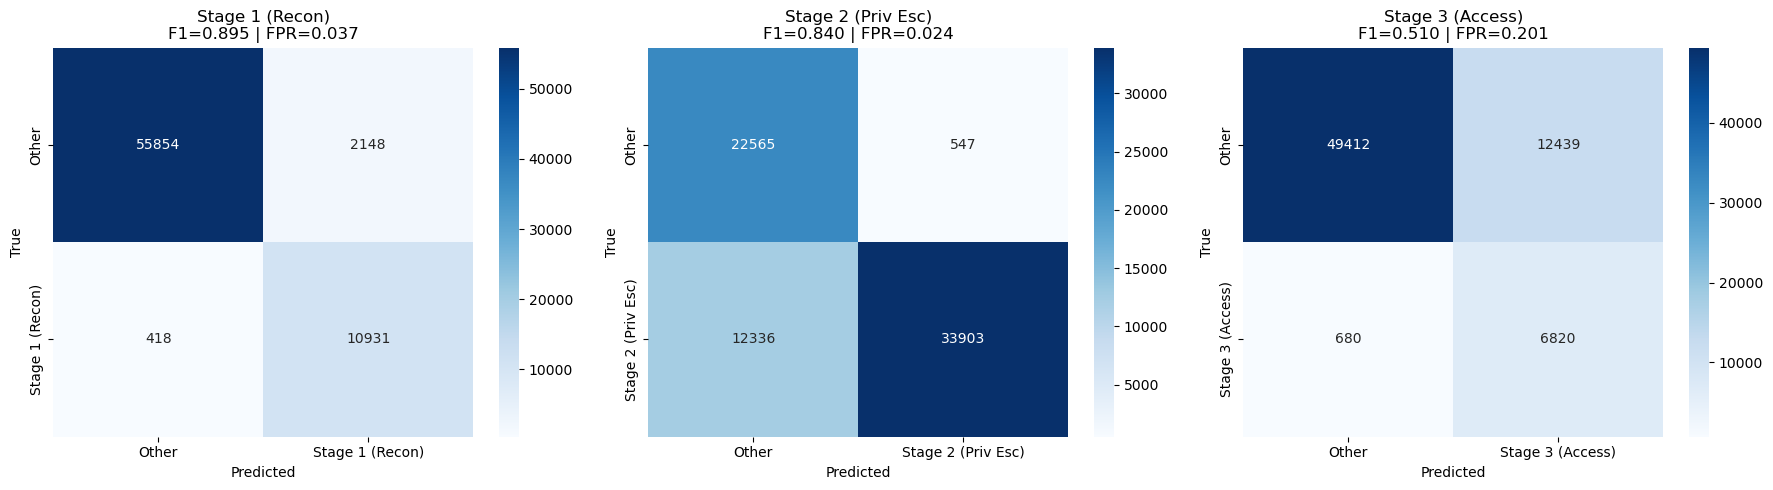

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ['Stage 1 (Recon)', 'Stage 2 (Priv Esc)', 'Stage 3 (Access)']
all_res = [results_s1, results_s2, results_s3]

for ax, lbl, res in zip(axes, labels, all_res):
    sns.heatmap(res['cm'], annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Other', lbl], yticklabels=['Other', lbl])
    ax.set_title(f"{lbl}\nF1={res['f1']:.3f} | FPR={res['fpr']:.3f}")
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Feature Importance


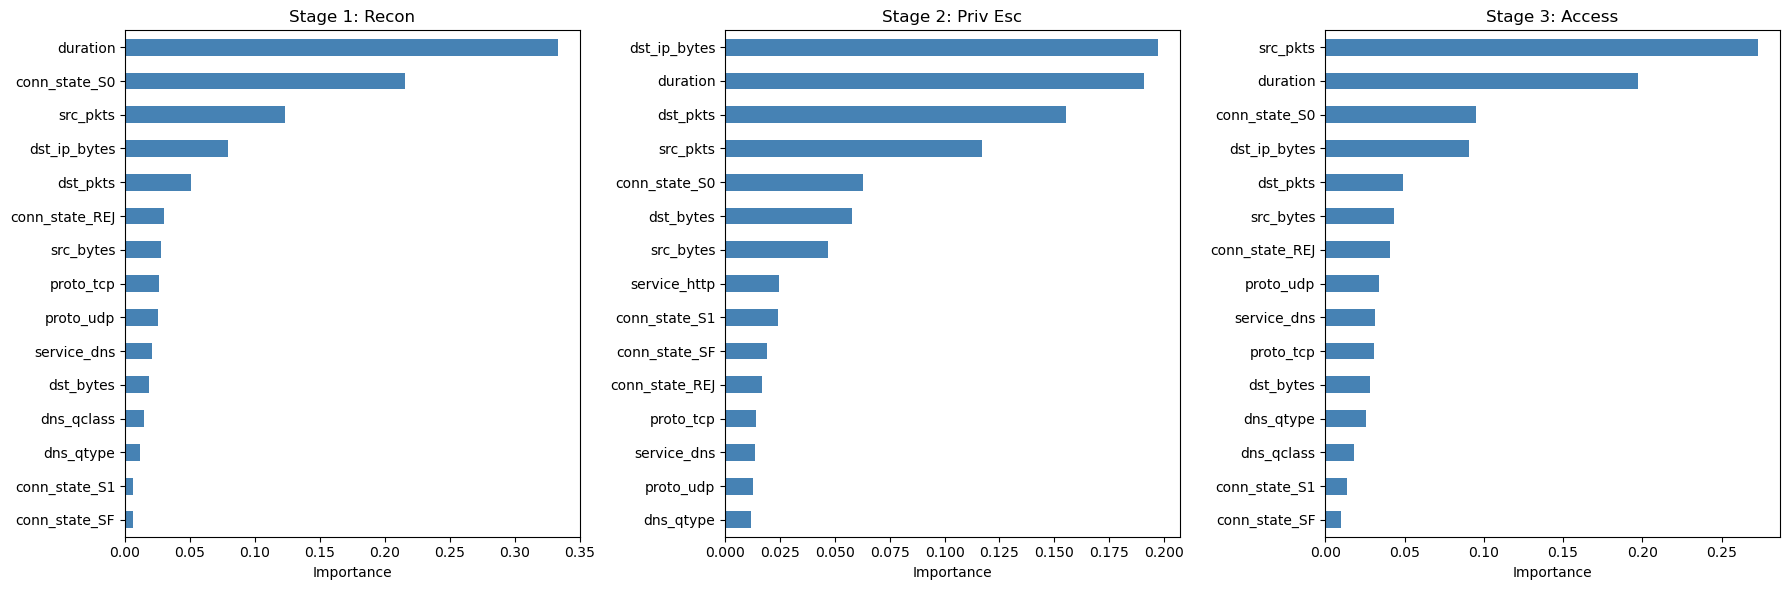

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
models = [rf_s1, rf_s2, rf_s3]
X_trains = [X_train_s1, X_train_s2, X_train_s3]
labels = ['Stage 1: Recon', 'Stage 2: Priv Esc', 'Stage 3: Access']

for ax, model, X_tr, title in zip(axes, models, X_trains, labels):
    imp = pd.Series(model.feature_importances_, index=X_tr.columns).nlargest(15)
    imp.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(title); ax.set_xlabel('Importance'); ax.invert_yaxis()

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## 12. Stage 3 Prediction from S1 & S2 Outputs

Using **test set only** (global split ensures no leakage).  
Aggregated per dst_ip — predict whether a target will be hit by Stage 3.

> Note: No dst_ip follows full S1->S2->S3 chain in this dataset.


In [64]:
import pandas as pd
import numpy as np

print("="*60)
print("MEMBANGUN DATASET AE PREDICTION (SESUAI PAPER)")
print("="*60)

def create_paper_ae_dataset(df_in):
    # 1. Pastikan data terurut berdasarkan waktu untuk menjaga sekuens (lists)
    df_sorted = df_in.sort_values(by=['dst_ip', 'timestamp'])
    
    # 2. Bikin "Lists" per user (dst_ip) untuk input RNN/Meta-Model nanti
    print("Mengekstrak list sekuensial per entitas...")
    grouped = df_sorted.groupby('dst_ip').agg(
        # Membuat list probabilitas dari waktu ke waktu (menggantikan embeddings paper)
        s1_prob_list=('prob_s1', list),
        s2_prob_list=('prob_s2', list),
        
        # Mengecek apakah IP ini BENAR-BENAR kena alert S1 dan S2
        s1_alert_count=('pred_s1', 'sum'),
        s2_alert_count=('pred_s2', 'sum'),
        
        # Label 1 jika diikuti S3, 0 jika tidak (sesuai paper)
        actual_s3=('is_s3', lambda x: (x == 1).sum() > 0)
    ).reset_index()
    
    # 3. FILTERING KETAT SESUAI PAPER:
    # "predicting if a user is going to be targeted... AFTER receiving a Reconnaissance and Privilege escalation"
    # Kita HANYA ambil IP yang punya riwayat serangan S1 DAN S2.
    paper_df = grouped[(grouped['s1_alert_count'] > 0) & (grouped['s2_alert_count'] > 0)].copy()
    
    # 4. Finalisasi format: dst_ip, list_1, list_2, label
    paper_df['label'] = paper_df['actual_s3'].astype(int)
    
    # Sisakan kolom yang diminta paper
    final_df = paper_df[['dst_ip', 's1_prob_list', 's2_prob_list', 'label']]
    
    return final_df

# Generate datasetnya
ae_train = create_paper_ae_dataset(df_train)
ae_test = create_paper_ae_dataset(df_test)

print(f"\n[HASIL FILTERING]")
print(f"AE Train Dataset: {len(ae_train)} targeted users")
print(f"AE Test Dataset:  {len(ae_test)} targeted users")

print(f"\n[DISTRIBUSI LABEL TRAIN (0 = Tidak Lanjut S3, 1 = Lanjut S3)]")
print(ae_train['label'].value_counts())

print(f"\n[DISTRIBUSI LABEL TEST]")
print(ae_test['label'].value_counts())

# Intip bentuk datanya
print("\n[PREVIEW AE DATASET]")
print(ae_train.head(3))

MEMBANGUN DATASET AE PREDICTION (SESUAI PAPER)
Mengekstrak list sekuensial per entitas...
Mengekstrak list sekuensial per entitas...

[HASIL FILTERING]
AE Train Dataset: 20 targeted users
AE Test Dataset:  20 targeted users

[DISTRIBUSI LABEL TRAIN (0 = Tidak Lanjut S3, 1 = Lanjut S3)]
0    17
1     3
Name: label, dtype: int64

[DISTRIBUSI LABEL TEST]
0    19
1     1
Name: label, dtype: int64

[PREVIEW AE DATASET]
            dst_ip                                       s1_prob_list  \
34   117.18.237.29  [0.03495147959501395, 0.02730370842630964, 0.0...   
68   13.35.148.106  [0.5105861381108981, 0.3186139441244673, 0.510...   
115  176.28.50.165  [0.05802466043191662, 0.11077938085429985, 0.5...   

                                          s2_prob_list  label  
34   [0.06213027002015567, 0.5873076897031055, 0.06...      0  
68   [0.47312666361535227, 0.5626222968547792, 0.47...      0  
115  [0.7108966425353594, 0.8246962091607941, 0.188...      0  


In [66]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("TRAINING RNN/LSTM UNTUK AE PREDICTION (STAGE 3)")
print("="*60)

# 1. PARAMETER PREPROCESSING
# Kita batasi panjang history maksimal per IP (misal 50 step terakhir)
MAX_TIMESTEPS = 50 

def prepare_rnn_data(df):
    X_s1 = pad_sequences(df['s1_prob_list'].values, maxlen=MAX_TIMESTEPS, padding='post', dtype='float32')
    X_s2 = pad_sequences(df['s2_prob_list'].values, maxlen=MAX_TIMESTEPS, padding='post', dtype='float32')
    
    # Gabungkan S1 dan S2 jadi 3D array: (Jumlah IP, Timesteps, Jumlah Fitur)
    # Shape target: (samples, MAX_TIMESTEPS, 2)
    X = np.stack((X_s1, X_s2), axis=-1)
    y = df['label'].values
    return X, y

print(f"Memproses sequence data (Max timesteps = {MAX_TIMESTEPS})...")
X_train_rnn, y_train_rnn = prepare_rnn_data(ae_train)
X_test_rnn, y_test_rnn = prepare_rnn_data(ae_test)

print(f"Shape X_train: {X_train_rnn.shape}")
print(f"Shape X_test:  {X_test_rnn.shape}")

# 2. HANDLE KETIMPANGAN DATA (Class Weights)
# Karena label '1' cuma ada 3 biji, kita harus kasih bobot hukuman yg berat kalau model salah tebak label '1'
classes = np.unique(y_train_rnn)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_rnn)
class_weight_dict = {classes[i]: weights[i] for i in range(len(classes))}
print(f"Class Weights: {class_weight_dict}")

# 3. BANGUN ARSITEKTUR RNN/LSTM
model = Sequential([
    # Masking layer buat ngasih tau model: "Kalo angkanya 0.0 hasil padding, abaikan aja"
    Masking(mask_value=0., input_shape=(MAX_TIMESTEPS, 2)),
    
    # LSTM layer kecil aja karena datanya super dikit (menghindari overfit)
    LSTM(16, return_sequences=False),
    
    # Dropout buat matiin sebagian neuron secara acak pas training (mencegah hapalan)
    Dropout(0.3),
    
    # Output layer: 1 neuron (karena biner 0 atau 1) dengan aktivasi sigmoid
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

# 4. TRAINING MODEL
print("\nMulai Training...")
# Epoch jangan banyak-banyak, batch size kecilin karena sampel dikit
history = model.fit(
    X_train_rnn, y_train_rnn,
    epochs=20,
    batch_size=4,
    class_weight=class_weight_dict,
    verbose=1
)

# 5. EVALUASI MODEL
print("\n" + "="*50)
print("EVALUASI MODEL DI DATA TEST")
print("="*50)

# Model ngeluarin probabilitas, kita buletin jadi 0 atau 1 (Threshold 0.5)
y_pred_probs = model.predict(X_test_rnn)
y_pred_rnn = (y_pred_probs > 0.5).astype(int).flatten()

print(classification_report(y_test_rnn, y_pred_rnn, target_names=['Safe (0)', 'S3 Attack (1)'], zero_division=0))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test_rnn, y_pred_rnn)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Safe', 'S3 Attack'], yticklabels=['Safe', 'S3 Attack'])
plt.title('RNN/LSTM Prediction (Stage 3 Access Exploitation)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

ModuleNotFoundError: No module named 'tensorflow'

## 13. Conclusion

### Results:
- 3 RF classifiers with **stratified global IP-split** (20% per-stage IPs to test)
- Every stage guaranteed to have samples in both train and test
- No cross-stage IP leakage

### Key dataset limitation:
- **0 dst_ips follow S1->S2->S3 chain** — limits CKC-based prediction
- Paper's own AE prediction also had poor results (~30 samples)

### Next steps:
1. Add GCN context-aware model
2. Stack GCN + RF with logistic regression meta-model
3. Multi-input RNN for Stage 3 prediction
4. Find dataset with actual multi-stage attack sequences
